# 01 — what is actually in the corpus

**Summary.** The corpus is not a neutral sample of art, and three of its skews change how every
later number reads:

1. **Only 14.65% of the manifest is 2D** (2,930 of 20,000). Every sheet-shaped measurement in this
   project — ground, margin, edge contact — applies to a minority of the corpus, and the rest are
   objects photographed against a museum's backdrop. The Met alone is **91% objects**.
2. **The corpus is bimodal in time and the split runs along museum lines.** The Met's median work
   begins in **664 BCE**; the Art Institute's begins in **1595 CE**. 39.2% of dated works are BCE.
   There is no single "period" here to reason about.
3. **`date_begin` contains garbage at both ends** — the minimum is −1,824,528,578 and the maximum is
   1,486,490. Museum date fields are free text upstream and the parse does not reject nonsense. 113
   rows (0.57%) are outside −4000..2026 and this notebook drops them *before* quoting any quantile.

Classification is a long tail (7,073 distinct labels, top 20 covering 15.6%) and **12 of the top 20
labels are used by exactly one museum** — `Ceramic`, `ceramics` and `earthenware` are three separate
labels here. That is most of why metadata neighbours are 93.6% same-museum while appearance
neighbours are 66.3% (chance 39.0%).

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import kusama as k

m = k.load_manifest()
b = k.band()

## Museums, and the share each contributed

museum
met    10000
aic     6817
cma     3183

P(two random works share a museum) = 0.3897, vs 1/3 = 0.3333 if equal


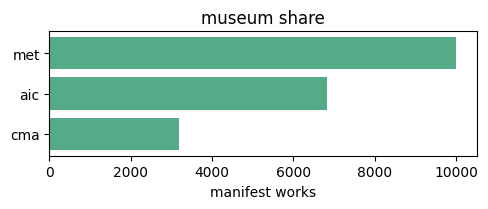

In [2]:
counts = m.museum.value_counts()
print(counts.to_string())
print(f"\nP(two random works share a museum) = {k.museum_chance():.4f}, vs 1/3 = {1/3:.4f} if equal")
fig, ax = plt.subplots(figsize=(5, 2.2))
ax.barh(counts.index[::-1], counts.values[::-1], color="#5a8")
ax.set_xlabel("manifest works"); ax.set_title("museum share"); fig.tight_layout()
plt.show()

## Dimensionality — the 2D minority

`dimensionalityOf` reads the medium and classification strings, not the pixels. "2d" means the work
is a drawing, print, photograph or painting; "object" means it is a thing photographed against a
background. The distinction matters because a photograph *of an object* has a ground that belongs to
the museum's studio, not to the artist — which is why only 9 of 1,500 sampled images turned out to
be sheets with a measurable ground.

In [3]:
dim = m.dimensionality.value_counts()
print(dim.to_string())
share2d = (m.dimensionality == "2d").mean()
print(f"\n2D share of the manifest: {share2d*100:.2f}%  ({(m.dimensionality == '2d').sum():,} works)")
print("An influence set far from this share is being steered by its queries — see notebook 04.\n")
print(m.groupby("museum").dimensionality.value_counts(normalize=True).unstack().fillna(0).round(3).to_string())
print("\nThe Met is 91% objects. The 2D minority is mostly the Art Institute's.")

dimensionality
object     16126
2d          2930
unknown      944

2D share of the manifest: 14.65%  (2,930 works)
An influence set far from this share is being steered by its queries — see notebook 04.

dimensionality     2d  object  unknown
museum                                
aic             0.276   0.682    0.043
cma             0.167   0.748    0.084
met             0.052   0.910    0.039

The Met is 91% objects. The 2D minority is mostly the Art Institute's.


## Dates, after saying what had to be thrown away

The honest order is: count the nonsense first, then clip, then describe. Reporting a median without
naming the clip is reporting a number that depends on a decision the reader cannot see.

In [4]:
d_raw = m.date_begin.dropna().astype("int64")
bad_lo, bad_hi = d_raw < -4000, d_raw > 2026
print(f"{len(d_raw):,} works carry a date_begin")
print(f"  range as parsed: {d_raw.min():,} .. {d_raw.max():,}   <- both ends are impossible")
print(f"  {bad_lo.sum()} below -4000 and {bad_hi.sum()} above 2026 — {(bad_lo|bad_hi).sum()} rows "
      f"({(bad_lo|bad_hi).mean():.3%}) dropped for everything below")
d = d_raw[~(bad_lo | bad_hi)]
qs = [0, .1, .25, .5, .75, .9, 1]
print("\n  quantiles:", "  ".join(f"{int(q*100)}%={int(d.quantile(q))}" for q in qs))
print(f"  BCE share: {(d < 0).mean():.1%}")
print("\nby museum (median date_begin, after the clip):")
mm = m.assign(dc=d_raw.where(~(bad_lo | bad_hi)))
print(mm.groupby("museum").dc.median().round(0).to_string())

19,831 works carry a date_begin
  range as parsed: -1,824,528,578 .. 1,486,490   <- both ends are impossible
  112 below -4000 and 1 above 2026 — 113 rows (0.570%) dropped for everything below

  quantiles: 0%=-4000  10%=-1650  25%=-1153  50%=901  75%=1720  90%=1850  100%=2020
  BCE share: 39.2%

by museum (median date_begin, after the clip):
museum
aic    1595.0
cma    1074.0
met    -664.0


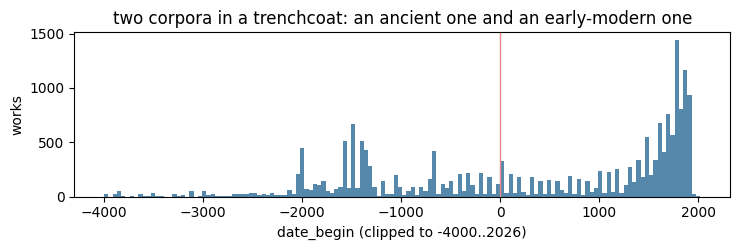

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.hist(d, bins=140, color="#58a")
ax.axvline(0, color="#e88", lw=1)
ax.set_xlabel("date_begin (clipped to -4000..2026)"); ax.set_ylabel("works")
ax.set_title("two corpora in a trenchcoat: an ancient one and an early-modern one")
fig.tight_layout(); plt.show()

## Classification: a long tail, and it is museum-private

The baseline is the entropy of a uniform draw over the same number of classes. The corpus sits far
below it, so a handful of classes carry most of the works. The more interesting column is the last
one: how many of the three museums use each label at all.

In [6]:
cl = m.classification.fillna("(none)").value_counts()
print(f"{len(cl):,} distinct classifications; top 20 cover {cl.head(20).sum()/len(m):.1%} of the manifest\n")
top = cl.head(20)
by_museum = (m[m.classification.isin(top.index)]
             .groupby("classification").museum.nunique().reindex(top.index))
for name, n in top.items():
    flag = "  <- one museum only" if by_museum[name] == 1 else ""
    print(f"  {n:>6,}  {name[:38]:<38}  {by_museum[name]}/3 museums{flag}")
p = (cl / cl.sum()).values
H = -(p * np.log2(p)).sum()
print(f"\nentropy {H:.3f} bits vs {np.log2(len(cl)):.3f} bits if uniform over the same {len(cl):,} classes")
print(f"{(by_museum == 1).sum()} of the top 20 labels are used by exactly ONE museum.")
print("Note 'Ceramic' / 'ceramics' / 'earthenware' are three different labels here. The vocabulary is")
print("not shared, which is most of why metadata neighbours are 93.6% same-museum (chance 39.0%).")

7,073 distinct classifications; top 20 cover 15.6% of the manifest

     272  Sculpture                               2/3 museums
     255  Metalwork                               2/3 museums
     246  Ceramic                                 1/3 museums  <- one museum only
     222  Jewelry                                 2/3 museums
     181  vessel                                  1/3 museums  <- one museum only
     170  Coins                                   2/3 museums
     169  earthenware                             1/3 museums  <- one museum only
     151  Textile                                 2/3 museums
     144  ceramics                                1/3 museums  <- one museum only
     141  bronze                                  1/3 museums  <- one museum only
     140  textile                                 1/3 museums  <- one museum only
     136  Jade                                    2/3 museums
     135  Painting                                2/3 museums
     1

## Image geometry

Aspect ratio is the one purely physical column. It is a fact about museum photography before it is a
fact about art.

19,889 images carry a size; aspect median 0.983, 6.2% within 2% of square, 51.2% portrait


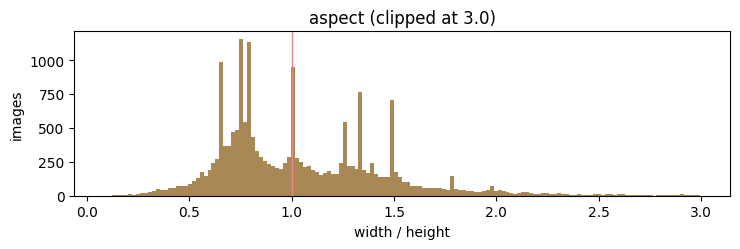

In [7]:
a = m.aspect.dropna()
print(f"{len(a):,} images carry a size; aspect median {a.median():.3f}, "
      f"{(a.between(0.98, 1.02)).mean():.1%} within 2% of square, {(a < 1).mean():.1%} portrait")
fig, ax = plt.subplots(figsize=(7.5, 2.6))
ax.hist(a[a < 3], bins=150, color="#a85")
ax.axvline(1.0, color="#e88", lw=1)
ax.set_xlabel("width / height"); ax.set_ylabel("images"); ax.set_title("aspect (clipped at 3.0)")
fig.tight_layout(); plt.show()

## Scratch

In [8]:
# yours